In [1]:
"""
Domain-adapt Layer 1's IMAGE branch to PAD-UFES phone images, WITHOUT touching
the metadata branch or the fusion head, and WITHOUT forgetting HAM dermoscopy.

Strategy:
  - freeze metadata_model + fusion classifier (the "not the metadata" part, and
    it keeps the existing decision boundary fixed so adapted image features must
    stay compatible with it)
  - freeze early image_model blocks, fine-tune only the late blocks + img head
  - train on a 50/50 HAM+PAD mix (sampler), so the model predicts on BOTH
    domains. Mixing also restores df/vasc (PAD has neither; HAM supplies them).
  - PAD metadata is mapped onto HAM's stored encoders so the frozen metadata
    branch receives inputs in the layout it was trained on.

Runs COLD from the saved checkpoint (no training session needed). Colab, GPU.
Set CKPT to your 299px multimodal file. Paste each # %% into a cell.

WARNING you must act on: adapting the image branch shifts the 1280-d feature
space. After this you MUST re-fit OOD (ood_scores_mobilenet.npz), re-sweep the
gate thresholds, and re-score the GOA head on the new routing. The mix keeps
HAM ~stable so those move a little, not a lot — but "a little" still needs
re-measuring before you quote a pipeline number.
"""


'\nDomain-adapt Layer 1\'s IMAGE branch to PAD-UFES phone images, WITHOUT touching\nthe metadata branch or the fusion head, and WITHOUT forgetting HAM dermoscopy.\n\nStrategy:\n  - freeze metadata_model + fusion classifier (the "not the metadata" part, and\n    it keeps the existing decision boundary fixed so adapted image features must\n    stay compatible with it)\n  - freeze early image_model blocks, fine-tune only the late blocks + img head\n  - train on a 50/50 HAM+PAD mix (sampler), so the model predicts on BOTH\n    domains. Mixing also restores df/vasc (PAD has neither; HAM supplies them).\n  - PAD metadata is mapped onto HAM\'s stored encoders so the frozen metadata\n    branch receives inputs in the layout it was trained on.\n\nRuns COLD from the saved checkpoint (no training session needed). Colab, GPU.\nSet CKPT to your 299px multimodal file. Paste each # %% into a cell.\n\nWARNING you must act on: adapting the image branch shifts the 1280-d feature\nspace. After this you M

In [7]:
# %% ===================================================== CELL 1: setup + load ckpt
import os, glob, time, json
import numpy as np, pandas as pd, torch, torch.nn as nn, torch.nn.functional as F
from PIL import Image
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as T
from torchvision.models import mobilenet_v3_large
from sklearn.metrics import f1_score, accuracy_score, classification_report, confusion_matrix

from google.colab import drive
drive.mount("/content/drive", force_remount=False)
import kagglehub

OUT   = "/content/drive/MyDrive/amsdds/mobilenetv4299"
CKPT  = f"{OUT}/multimodal_mobilenetv3.pt"          # <-- your 299px multimodal checkpoint
HAM_CACHE, PAD_CACHE = "/content/ham_cache", "/content/pad_cache"
SEED, IMG_SIZE, BATCH = 42, 299, 32
UNFREEZE_FROM = 11          # mobilenet .features has 17 blocks; train [11:] + head
PAD_SHARE = 0.5            # fraction of each batch drawn from PAD (domain balance)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
os.makedirs(HAM_CACHE, exist_ok=True)
os.makedirs(PAD_CACHE, exist_ok=True)

torch.manual_seed(SEED)
np.random.seed(SEED)

ck = torch.load(CKPT, map_location=DEVICE, weights_only=False)
CLASSES = ck["classes"]; CI = {c: i for i, c in enumerate(CLASSES)}
SEXCAT, LOCCAT = ck["sex_categories"], ck["location_categories"]
AGE_MU, AGE_SD, META_DIM = ck["age_mean"], ck["age_std"], ck["metadata_dim"]
print("classes:", CLASSES, "| meta_dim:", META_DIM)
print("loc categories:", LOCCAT)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
classes: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc'] | meta_dim: 19
loc categories: ['abdomen', 'acral', 'back', 'chest', 'ear', 'face', 'foot', 'genital', 'hand', 'lower extremity', 'neck', 'scalp', 'trunk', 'unknown', 'upper extremity']


In [8]:
# %% ===================================================== CELL 2: build dataframes
DHAM = kagglehub.dataset_download("kmader/skin-cancer-mnist-ham10000")
DPAD = kagglehub.dataset_download("mahdavi1202/skin-cancer")

# ---- HAM (reuse the frozen split so HAM test stays a true held-out set)
ham = pd.read_csv(f"{OUT}/splits.csv")
hsrc = {os.path.splitext(os.path.basename(p))[0]: p for p in glob.glob(f"{DHAM}/**/*.jpg", recursive=True)}
ham["src"] = ham.image_id.map(hsrc)
ham["path"] = ham.image_id.map(lambda i: f"{HAM_CACHE}/{i}.jpg")
ham["dataset"] = "ham"
ham = ham[["src", "path", "y", "split", "age", "sex", "localization", "dataset"]]

# ---- PAD-UFES: map classes + metadata onto HAM's schema, lesion-grouped split
pcsv = next(p for p in glob.glob(f"{DPAD}/**/*.csv", recursive=True))
pad = pd.read_csv(pcsv); pad.columns = [c.strip().lower() for c in pad.columns]
pimg = {os.path.basename(p): p for p in glob.glob(f"{DPAD}/**/*.png", recursive=True)}
CLSMAP = {"ACK": "akiec", "BCC": "bcc", "SCC": "akiec", "MEL": "mel", "NEV": "nv", "SEK": "bkl"}
REGMAP = {"arm": "upper extremity", "forearm": "upper extremity", "hand": "hand",
          "thigh": "lower extremity", "foot": "foot", "face": "face", "nose": "face",
          "lip": "face", "ear": "ear", "scalp": "scalp", "neck": "neck", "chest": "chest",
          "abdomen": "abdomen", "back": "back"}
pad["dx"] = pad.diagnostic.str.upper().map(CLSMAP)
pad = pad[pad.dx.notna()].copy()
pad["y"] = pad.dx.map(CI)
pad["src"] = pad.img_id.map(pimg)
pad["path"] = pad.img_id.map(lambda i: f"{PAD_CACHE}/{i}")
pad["age"] = pd.to_numeric(pad.age, errors="coerce")
pad["sex"] = pad.gender.astype(str).str.lower().where(pad.gender.notna(), "unknown")
pad["localization"] = pad.region.astype(str).str.lower().map(REGMAP).fillna("unknown")
assert pad.src.isna().sum() == 0, "some PAD images missing"

from sklearn.model_selection import StratifiedGroupKFold
sgkf = StratifiedGroupKFold(5, shuffle=True, random_state=SEED)
fold = list(sgkf.split(pad, pad.y, groups=pad.lesion_id))
pad["split"] = "train"
pad.iloc[fold[0][1], pad.columns.get_loc("split")] = "test"
pad.iloc[fold[1][1], pad.columns.get_loc("split")] = "val"
assert pad.groupby("lesion_id").split.nunique().max() == 1, "PAD lesion leaked"
pad["dataset"] = "pad"
pad = pad[["src", "path", "y", "split", "age", "sex", "localization", "dataset"]]

df = pd.concat([ham, pad], ignore_index=True)
print("HAM:", ham.split.value_counts().to_dict())
print("PAD:", pad.split.value_counts().to_dict())
print("PAD class spread:", pad.groupby(pad.y).size().to_dict())

Using Colab cache for faster access to the 'skin-cancer-mnist-ham10000' dataset.
Using Colab cache for faster access to the 'skin-cancer' dataset.
HAM: {'train': 7116, 'val': 1458, 'test': 1441}
PAD: {'train': 1405, 'val': 448, 'test': 445}
PAD class spread: {0: 922, 1: 845, 2: 235, 4: 52, 5: 244}


In [10]:
# %% ===================================================== CELL 3: cache PAD at 299 (CC)
def shades_of_gray(a, power=6):
    a = a.astype(np.float32)
    v = np.power(np.mean(np.power(a, power), (0, 1)), 1.0 / power)
    v = v / (np.sqrt((v ** 2).sum()) + 1e-8)
    return np.clip(a / (v * np.sqrt(3) + 1e-8), 0, 255).astype(np.uint8)

def build(r):
    if os.path.exists(r.path): return
    im = Image.open(r.src).convert("RGB"); w, h = im.size; s = 324 / min(w, h)   # 299*1.08
    im = im.resize((round(w * s), round(h * s)), Image.BICUBIC)
    Image.fromarray(shades_of_gray(np.array(im))).save(r.path, quality=95)

todo = df[[not os.path.exists(p) for p in df.path]]
if len(todo):
    from concurrent.futures import ThreadPoolExecutor
    t0 = time.time()
    with ThreadPoolExecutor(8) as ex: list(ex.map(build, list(todo.itertuples())))
    print(f"cached {len(todo)} in {time.time()-t0:.0f}s")
else:
    print("caches ready")

cached 12313 in 372s


In [11]:
import os

print(os.path.exists("/content/ham_cache/ISIC_0027419.jpg"))
print(os.listdir("/content/ham_cache")[:10])

True
['ISIC_0033568.jpg', 'ISIC_0029930.jpg', 'ISIC_0033238.jpg', 'ISIC_0026454.jpg', 'ISIC_0032559.jpg', 'ISIC_0032788.jpg', 'ISIC_0032416.jpg', 'ISIC_0026398.jpg', 'ISIC_0027786.jpg', 'ISIC_0031977.jpg']


In [12]:
# %% ===================================================== CELL 4: datasets + metadata
MEAN, STD = (0.485, 0.456, 0.406), (0.229, 0.224, 0.225)
train_tf = T.Compose([T.RandomResizedCrop(IMG_SIZE, scale=(0.65, 1.0), ratio=(0.85, 1.18)),
    T.RandomHorizontalFlip(), T.RandomVerticalFlip(), T.RandomApply([T.RandomRotation(30)], p=0.5),
    T.ColorJitter(0.35, 0.35, 0.25, 0.03), T.RandomApply([T.GaussianBlur(5, (0.1, 1.5))], p=0.25),
    T.ToTensor(), T.Normalize(MEAN, STD)])
eval_tf = T.Compose([T.Resize(324), T.CenterCrop(IMG_SIZE), T.ToTensor(), T.Normalize(MEAN, STD)])

def encode_meta(r):
    age = AGE_MU if pd.isna(r.age) else r.age
    sex = str(r.sex) if pd.notna(r.sex) else "unknown"
    loc = str(r.localization) if pd.notna(r.localization) else "unknown"
    sv = [float(sex == c) for c in SEXCAT]
    lv = [float(loc == c) for c in LOCCAT]
    return np.array([(float(age) - AGE_MU) / AGE_SD] + sv + lv, np.float32)

class SkinDS(Dataset):
    def __init__(self, frame, tf):
        self.f = frame.reset_index(drop=True); self.tf = tf
        self.M = np.stack([encode_meta(r) for r in self.f.itertuples()])
    def __len__(self): return len(self.f)
    def __getitem__(self, i):
        r = self.f.iloc[i]
        return self.tf(Image.open(r.path).convert("RGB")), torch.tensor(self.M[i]), int(r.y)

tr = df[df.split == "train"].reset_index(drop=True)
ham_te = df[(df.split == "test") & (df.dataset == "ham")]
pad_te = df[(df.split == "test") & (df.dataset == "pad")]
comb_va = df[df.split == "val"]

# 50/50 HAM:PAD sampler
is_pad = (tr.dataset == "pad").values
wt = np.where(is_pad, PAD_SHARE / is_pad.sum(), (1 - PAD_SHARE) / (~is_pad).sum())
sampler = WeightedRandomSampler(wt, num_samples=len(tr), replacement=True)
dl_tr = DataLoader(SkinDS(tr, train_tf), BATCH, sampler=sampler, num_workers=2,
                   pin_memory=True, drop_last=True, persistent_workers=True)
dl_ham = DataLoader(SkinDS(ham_te, eval_tf), 64, num_workers=2)
dl_pad = DataLoader(SkinDS(pad_te, eval_tf), 64, num_workers=2)
dl_va = DataLoader(SkinDS(comb_va, eval_tf), 64, num_workers=2)

In [13]:
# %% ===================================================== CELL 5: model + freeze plan
class MultiModalMobileNetV3(nn.Module):
    def __init__(self, metadata_dim, num_classes):
        super().__init__()
        self.image_model = mobilenet_v3_large()
        self.image_model.classifier[3] = nn.Identity()
        self.metadata_model = nn.Sequential(nn.Linear(metadata_dim, 64), nn.ReLU(),
                                            nn.Dropout(0.2), nn.Linear(64, 32), nn.ReLU())
        self.classifier = nn.Sequential(nn.Linear(1280 + 32, 128), nn.ReLU(),
                                        nn.Dropout(0.3), nn.Linear(128, num_classes))
    def forward(self, x, m):
        return self.classifier(torch.cat([self.image_model(x), self.metadata_model(m)], 1))

model = MultiModalMobileNetV3(META_DIM, len(CLASSES)).to(DEVICE)
model.load_state_dict(ck["model_state"]); print("loaded pretrained multimodal weights")
# freeze metadata branch + fusion head entirely (the "not the metadata" constraint)
for p in model.metadata_model.parameters(): p.requires_grad_(False)
for p in model.classifier.parameters(): p.requires_grad_(False)
# freeze early image blocks; adapt late blocks + image head
for i, blk in enumerate(model.image_model.features):
    req = i >= UNFREEZE_FROM
    for p in blk.parameters(): p.requires_grad_(req)
for p in model.image_model.classifier.parameters(): p.requires_grad_(True)  # img-side 960->1280
trainable = [p for p in model.parameters() if p.requires_grad]
print(f"trainable tensors: {sum(p.requires_grad for p in model.parameters())} "
      f"/ {len(list(model.parameters()))}  ({sum(p.numel() for p in trainable)/1e6:.1f}M params)")

counts = np.bincount(tr.y.values, minlength=len(CLASSES)).astype(np.float32)
w = np.ones(len(CLASSES), np.float32); nz = counts > 0
w[nz] = np.clip((1/np.sqrt(counts[nz])) / (1/np.sqrt(counts[nz])).min(), 1.0, 2.0)
lossfn = nn.CrossEntropyLoss(weight=torch.tensor(w, device=DEVICE), label_smoothing=0.05)
scaler = torch.amp.GradScaler("cuda", enabled=DEVICE == "cuda")

@torch.no_grad()
def evalf1(loader):
    model.eval(); L, Y = [], []
    for x, m, y in loader:
        with torch.autocast("cuda", torch.float16, enabled=DEVICE == "cuda"):
            L.append(model(x.to(DEVICE), m.to(DEVICE)).float().cpu())
        Y.append(y)
    L, Y = torch.cat(L).argmax(1).numpy(), torch.cat(Y).numpy()
    return f1_score(Y, L, average="macro"), accuracy_score(Y, L)

loaded pretrained multimodal weights
trainable tensors: 70 / 180  (4.0M params)


In [14]:
# %% ===================================================== CELL 6: adapt
opt = torch.optim.AdamW(trainable, lr=5e-5, weight_decay=1e-4)
EPOCHS = 15
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, EPOCHS)
best, best_state = -1, None
for ep in range(EPOCHS):
    model.train(); t0 = time.time()
    for x, m, y in dl_tr:
        x, m, y = x.to(DEVICE), m.to(DEVICE), y.to(DEVICE)
        opt.zero_grad(set_to_none=True)
        with torch.autocast("cuda", torch.float16, enabled=DEVICE == "cuda"):
            loss = lossfn(model(x, m), y)
        scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
    sched.step()
    f_va, _ = evalf1(dl_va); f_ham, a_ham = evalf1(dl_ham); f_pad, a_pad = evalf1(dl_pad)
    score = (f_ham + f_pad) / 2                      # select on BOTH domains, not just PAD
    if score > best:
        best = score; best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
        torch.save(best_state, f"{OUT}/layer1_adapted_ckpt_tmp.pt")
    print(f"ep {ep:2d}  val {f_va:.3f} | HAM F1 {f_ham:.3f}/acc {a_ham:.3f} | "
          f"PAD F1 {f_pad:.3f}/acc {a_pad:.3f}  ({time.time()-t0:.0f}s)")
model.load_state_dict(best_state)
print(f"\nbest mean(HAM,PAD) macro-F1: {best:.4f}")


ep  0  val 0.661 | HAM F1 0.665/acc 0.840 | PAD F1 0.629/acc 0.688  (177s)
ep  1  val 0.689 | HAM F1 0.658/acc 0.830 | PAD F1 0.682/acc 0.717  (154s)
ep  2  val 0.666 | HAM F1 0.664/acc 0.831 | PAD F1 0.696/acc 0.724  (155s)
ep  3  val 0.686 | HAM F1 0.688/acc 0.829 | PAD F1 0.720/acc 0.746  (156s)
ep  4  val 0.683 | HAM F1 0.698/acc 0.835 | PAD F1 0.722/acc 0.744  (154s)
ep  5  val 0.690 | HAM F1 0.695/acc 0.838 | PAD F1 0.711/acc 0.739  (153s)
ep  6  val 0.685 | HAM F1 0.703/acc 0.837 | PAD F1 0.703/acc 0.737  (152s)
ep  7  val 0.714 | HAM F1 0.720/acc 0.840 | PAD F1 0.723/acc 0.737  (153s)
ep  8  val 0.733 | HAM F1 0.745/acc 0.845 | PAD F1 0.711/acc 0.746  (151s)
ep  9  val 0.712 | HAM F1 0.731/acc 0.840 | PAD F1 0.684/acc 0.744  (150s)
ep 10  val 0.720 | HAM F1 0.742/acc 0.842 | PAD F1 0.683/acc 0.742  (151s)
ep 11  val 0.721 | HAM F1 0.730/acc 0.844 | PAD F1 0.683/acc 0.739  (150s)
ep 12  val 0.717 | HAM F1 0.732/acc 0.843 | PAD F1 0.692/acc 0.746  (152s)
ep 13  val 0.718 | HAM F1

In [15]:
# %% ===================================================== CELL 7: final report + save
print("=== HAM test (did it forget dermoscopy?) ===")
f_ham, a_ham = evalf1(dl_ham); print(f"macro-F1 {f_ham:.4f}  acc {a_ham:.4f}")
print("=== PAD-UFES test (does it work on phone images now?) ===")
f_pad, a_pad = evalf1(dl_pad); print(f"macro-F1 {f_pad:.4f}  acc {a_pad:.4f}")

# recalibrate temperature on the combined val (image features moved)
@torch.no_grad()
def logits(loader):
    L, Y = [], []
    for x, m, y in loader:
        with torch.autocast("cuda", torch.float16, enabled=DEVICE == "cuda"):
            L.append(model(x.to(DEVICE), m.to(DEVICE)).float().cpu())
        Y.append(y)
    return torch.cat(L), torch.cat(Y)
lv, yv = logits(dl_va); lv, yv = lv.to(DEVICE), yv.to(DEVICE)
logT = torch.zeros(1, device=DEVICE, requires_grad=True)
topt = torch.optim.LBFGS([logT], lr=0.1, max_iter=60)
def _cl(): topt.zero_grad(); l = F.cross_entropy(lv / logT.exp(), yv); l.backward(); return l
topt.step(_cl); TEMP = float(logT.exp().detach()); print(f"\nrecalibrated T = {TEMP:.3f}")

out = dict(ck)                                       # keep classes/encoders identical
out["model_state"] = best_state
out["temperature"] = TEMP
out["img_size"] = IMG_SIZE
out["adapted_on"] = "ham+pad-ufes-20 (image branch only, head frozen)"
out["metrics"] = {"ham_test_f1": f_ham, "ham_test_acc": a_ham,
                  "pad_test_f1": f_pad, "pad_test_acc": a_pad}
torch.save(out, f"{OUT}/layer1_multimodal_domainadapted.pt")
print("saved layer1_multimodal_domainadapted.pt")
print("\nNEXT (do not skip): re-fit OOD, re-sweep gate, re-score GOA on this model.")

=== HAM test (did it forget dermoscopy?) ===
macro-F1 0.7448  acc 0.8446
=== PAD-UFES test (does it work on phone images now?) ===
macro-F1 0.7107  acc 0.7461

recalibrated T = 1.058
saved layer1_multimodal_domainadapted.pt

NEXT (do not skip): re-fit OOD, re-sweep gate, re-score GOA on this model.


Classes: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
Sex categories: ['female', 'male', 'unknown']
Location categories: ['abdomen', 'acral', 'back', 'chest', 'ear', 'face', 'foot', 'genital', 'hand', 'lower extremity', 'neck', 'scalp', 'trunk', 'unknown', 'upper extremity']
Loaded adapted model.
Image size: (739, 415)


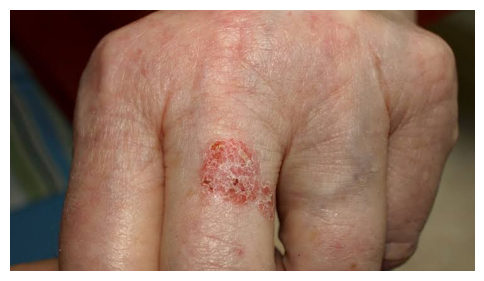


MODEL PREDICTION

Predicted class: bcc
Confidence:      0.3878

   bcc : 0.3878
 akiec : 0.2630
    nv : 0.1818
   bkl : 0.0842
  vasc : 0.0359
    df : 0.0300
   mel : 0.0173


In [25]:
# ============================================================
# EXTERNAL REAL-WORLD IMAGE TEST
# HAM 7-class domain-adapted model
# ============================================================

import torch
import torch.nn as nn
import torchvision.transforms as T
from torchvision.models import mobilenet_v3_large
from PIL import Image
import matplotlib.pyplot as plt
import urllib.request
from io import BytesIO
import numpy as np

# ------------------------------------------------------------
# 1. Load adapted model
# ------------------------------------------------------------

CKPT = f"{OUT}/layer1_multimodal_domainadapted.pt"

ck = torch.load(
    CKPT,
    map_location=DEVICE,
    weights_only=False
)

CLASSES = ck["classes"]
SEXCAT = ck["sex_categories"]
LOCCAT = ck["location_categories"]
AGE_MU = ck["age_mean"]
AGE_SD = ck["age_std"]
META_DIM = ck["metadata_dim"]

print("Classes:", CLASSES)
print("Sex categories:", SEXCAT)
print("Location categories:", LOCCAT)


# ------------------------------------------------------------
# 2. Recreate exact model architecture
# ------------------------------------------------------------

class MultiModalMobileNetV3(nn.Module):
    def __init__(self, metadata_dim, num_classes):
        super().__init__()

        self.image_model = mobilenet_v3_large()
        self.image_model.classifier[3] = nn.Identity()

        self.metadata_model = nn.Sequential(
            nn.Linear(metadata_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU()
        )

        self.classifier = nn.Sequential(
            nn.Linear(1280 + 32, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x, m):
        image_features = self.image_model(x)
        metadata_features = self.metadata_model(m)
        return self.classifier(
            torch.cat([image_features, metadata_features], dim=1)
        )


model = MultiModalMobileNetV3(
    META_DIM,
    len(CLASSES)
).to(DEVICE)

model.load_state_dict(ck["model_state"])
model.eval()

print("Loaded adapted model.")


# ------------------------------------------------------------
# 3. Paste an image URL here
# ------------------------------------------------------------

IMAGE_PATH = "/content/bowens.jpg"

img = Image.open(IMAGE_PATH).convert("RGB")

print("Image size:", img.size)

plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.axis("off")
plt.show()


# ------------------------------------------------------------
# 4. Shades-of-gray color constancy
#    Same idea used during adaptation
# ------------------------------------------------------------

def shades_of_gray(a, power=6):
    a = a.astype(np.float32)

    v = np.power(
        np.mean(np.power(a, power), (0, 1)),
        1.0 / power
    )

    v = v / (np.sqrt((v ** 2).sum()) + 1e-8)

    return np.clip(
        a / (v * np.sqrt(3) + 1e-8),
        0,
        255
    ).astype(np.uint8)


img_cc = Image.fromarray(
    shades_of_gray(np.array(img))
)


# ------------------------------------------------------------
# 5. Exact evaluation preprocessing
# ------------------------------------------------------------

eval_tf = T.Compose([
    T.Resize(324),
    T.CenterCrop(299),
    T.ToTensor(),
    T.Normalize(
        (0.485, 0.456, 0.406),
        (0.229, 0.224, 0.225)
    )
])

x = eval_tf(img_cc).unsqueeze(0).to(DEVICE)


# ------------------------------------------------------------
# 6. Neutral metadata
# ------------------------------------------------------------

# Use mean age
age = 0.0

# All-zero categorical encoding = unknown/neutral
# This avoids inventing patient information.
meta = np.zeros(META_DIM, dtype=np.float32)

# If "unknown" exists, explicitly activate it.
sex_start = 1

if "unknown" in [str(x).lower() for x in SEXCAT]:
    idx = [str(x).lower() for x in SEXCAT].index("unknown")
    meta[sex_start + idx] = 1.0

loc_start = 1 + len(SEXCAT)

if "unknown" in [str(x).lower() for x in LOCCAT]:
    idx = [str(x).lower() for x in LOCCAT].index("unknown")
    meta[loc_start + idx] = 1.0

meta = torch.tensor(meta, dtype=torch.float32).unsqueeze(0).to(DEVICE)


# ------------------------------------------------------------
# 7. Prediction
# ------------------------------------------------------------

with torch.no_grad():
    with torch.autocast(
        "cuda",
        torch.float16,
        enabled=DEVICE == "cuda"
    ):
        logits = model(x, meta).float()

probs = torch.softmax(logits, dim=1)[0]

pred_idx = probs.argmax().item()
pred_class = CLASSES[pred_idx]
confidence = probs[pred_idx].item()


# ------------------------------------------------------------
# 8. Print all 7 predictions
# ------------------------------------------------------------

print("\n==============================")
print("MODEL PREDICTION")
print("==============================")

print(f"\nPredicted class: {pred_class}")
print(f"Confidence:      {confidence:.4f}\n")

for cls, p in sorted(
    zip(CLASSES, probs.cpu().numpy()),
    key=lambda z: z[1],
    reverse=True
):
    print(f"{cls:>6s} : {p:.4f}")

In [ ]:
# OOD stuff

In [28]:
import torch, json, numpy as np, pandas as pd, glob, os
OUT = "/content/drive/MyDrive/amsdds/mobilenetv4299"
c = torch.load(f"{OUT}/layer1_multimodal_domainadapted.pt", map_location="cpu", weights_only=False)
print("== checkpoint keys:", list(c.keys()))
for k in c:
    if k in ("model_state","state","state_dict"):
        sd=c[k]; print("   state tensors:", len(sd))
        print("   fusion/meta keys:", [kk for kk in sd if "classifier" in kk or "metadata" in kk][:12])
        continue
    v=c[k]
    print(f"   {k} = {v if not hasattr(v,'__len__') or isinstance(v,str) else (v if len(str(v))<200 else type(v))}")

print("\n== splits.csv columns:", list(pd.read_csv(f'{OUT}/splits.csv', nrows=1).columns))
import kagglehub
DATA = kagglehub.dataset_download("kmader/skin-cancer-mnist-ham10000")
meta = glob.glob(f"{DATA}/**/HAM10000_metadata*.csv", recursive=True)
print("== HAM metadata csv:", meta[:1])
if meta:
    m=pd.read_csv(meta[0]); print("   columns:", list(m.columns))
    print("   sex values:", m.sex.dropna().unique().tolist())
    print("   localization values:", sorted(m.localization.dropna().unique().tolist()))
    print("   age NaN count:", m.age.isna().sum())

== checkpoint keys: ['model_state', 'classes', 'metadata_dim', 'sex_categories', 'location_categories', 'age_mean', 'age_std', 'metrics', 'temperature', 'img_size', 'adapted_on']
   state tensors: 318
   fusion/meta keys: ['image_model.classifier.0.weight', 'image_model.classifier.0.bias', 'metadata_model.0.weight', 'metadata_model.0.bias', 'metadata_model.3.weight', 'metadata_model.3.bias', 'classifier.0.weight', 'classifier.0.bias', 'classifier.3.weight', 'classifier.3.bias']
   classes = ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
   metadata_dim = 19
   sex_categories = ['female', 'male', 'unknown']
   location_categories = ['abdomen', 'acral', 'back', 'chest', 'ear', 'face', 'foot', 'genital', 'hand', 'lower extremity', 'neck', 'scalp', 'trunk', 'unknown', 'upper extremity']
   age_mean = 51.53242899533701
   age_std = 16.952723340294664
   metrics = {'ham_test_f1': 0.7448364875219785, 'ham_test_acc': 0.8445523941707148, 'pad_test_f1': 0.7107348921878456, 'pad_test_acc': 0.

In [30]:

# %% ===================================================== CELL 1: setup + load ckpt
import os, glob, time
import numpy as np, pandas as pd, torch, torch.nn as nn, torch.nn.functional as F
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from torchvision.models import mobilenet_v3_large
from sklearn.metrics import roc_auc_score

OUT = "/content/drive/MyDrive/amsdds/mobilenetv4299"# you are already %cd'd into amsdds
CACHE = "/content/ham_cache"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
MEAN, STD = (0.485, 0.456, 0.406), (0.229, 0.224, 0.225)

ck = torch.load(f"{OUT}/multimodal_mobilenetv3.pt", map_location=DEVICE, weights_only=False)
CLASSES = ck["classes"]; CI = {c: i for i, c in enumerate(CLASSES)}
SEX = ck["sex_categories"]; LOC = ck["location_categories"]
AGE_MU, AGE_SD, META_DIM = ck["age_mean"], ck["age_std"], ck["metadata_dim"]
print("classes:", CLASSES, "| meta_dim:", META_DIM, "| T:", round(ck["temperature"], 3))


classes: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc'] | meta_dim: 19 | T: 0.959


In [31]:

# %% ===================================================== CELL 2: rebuild the model
class MultiModalMobileNetV3(nn.Module):
    def __init__(self, metadata_dim, num_classes):
        super().__init__()
        self.image_model = mobilenet_v3_large()
        self.image_model.classifier[3] = nn.Identity()          # -> 1280-d image feature
        self.metadata_model = nn.Sequential(
            nn.Linear(metadata_dim, 64), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(64, 32), nn.ReLU())
        self.classifier = nn.Sequential(
            nn.Linear(1280 + 32, 128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, num_classes))
    def forward(self, x, meta):
        return self.classifier(torch.cat([self.image_model(x), self.metadata_model(meta)], 1))
    def image_features(self, x):
        return self.image_model(x)                              # the 1280-d penultimate

model = MultiModalMobileNetV3(META_DIM, len(CLASSES)).to(DEVICE)
model.load_state_dict(ck["model_state"]); model.eval()
print("model loaded, weights matched")


model loaded, weights matched


In [32]:

# %% ===================================================== CELL 3: splits + image cache
df = pd.read_csv(f"{OUT}/splits.csv")
src = {os.path.splitext(os.path.basename(p))[0]: p
       for p in glob.glob("/kaggle/input/**/*.jpg", recursive=True)}
if not src:   # kagglehub path if /kaggle not mounted
    import kagglehub
    D = kagglehub.dataset_download("kmader/skin-cancer-mnist-ham10000")
    src = {os.path.splitext(os.path.basename(p))[0]: p for p in glob.glob(f"{D}/**/*.jpg", recursive=True)}
df["src"] = df.image_id.map(src)
df["path"] = df.image_id.map(lambda i: f"{CACHE}/{i}.jpg")
assert df.src.isna().sum() == 0, "some HAM images not found"

def shades_of_gray(a, power=6):
    a = a.astype(np.float32)
    v = np.power(np.mean(np.power(a, power), (0, 1)), 1.0 / power)
    v = v / (np.sqrt((v ** 2).sum()) + 1e-8)
    return np.clip(a / (v * np.sqrt(3) + 1e-8), 0, 255).astype(np.uint8)

os.makedirs(CACHE, exist_ok=True)
def build(r):
    if os.path.exists(r.path): return
    im = Image.open(r.src).convert("RGB"); w, h = im.size; s = 256 / min(w, h)
    im = im.resize((round(w * s), round(h * s)), Image.BICUBIC)
    im.save(Image.fromarray(shades_of_gray(np.array(im))) and r.path or r.path)  # noqa
# (explicit version to avoid the walrus confusion)
def build(r):
    if os.path.exists(r.path): return
    im = Image.open(r.src).convert("RGB"); w, h = im.size; s = 256 / min(w, h)
    im = im.resize((round(w * s), round(h * s)), Image.BICUBIC)
    Image.fromarray(shades_of_gray(np.array(im))).save(r.path, quality=95)

need = sum(not os.path.exists(p) for p in df.path)
if need:
    from concurrent.futures import ThreadPoolExecutor
    t0 = time.time()
    with ThreadPoolExecutor(8) as ex: list(ex.map(build, list(df.itertuples())))
    print(f"cached {need} in {time.time()-t0:.0f}s")
else:
    print("cache ready")


cache ready


In [33]:

# %% ===================================================== CELL 4: re-encode metadata
def onehot(v, vocab):
    o = np.zeros(len(vocab), np.float32); o[vocab.index(v if v in vocab else "unknown")] = 1.0; return o
def encode(frame):
    M = np.zeros((len(frame), META_DIM), np.float32)
    for i, r in enumerate(frame.itertuples()):
        age = AGE_MU if pd.isna(r.age) else r.age
        sex = str(r.sex).strip().lower() if pd.notna(r.sex) else "unknown"
        loc = str(r.localization).strip().lower() if pd.notna(r.localization) else "unknown"
        M[i] = np.concatenate([[(age - AGE_MU) / AGE_SD], onehot(sex, SEX), onehot(loc, LOC)])
    return M

eval_tf = T.Compose([T.Resize(256), T.CenterCrop(224), T.ToTensor(), T.Normalize(MEAN, STD)])
class HAM(Dataset):
    def __init__(self, frame): self.f = frame.reset_index(drop=True)
    def __len__(self): return len(self.f)
    def __getitem__(self, i):
        r = self.f.iloc[i]
        return eval_tf(Image.open(r.path).convert("RGB")), int(r.y)

tr, va, te = (df[df.split == s] for s in ("train", "val", "test"))


In [34]:

# %% ===================================================== CELL 5: image features
@torch.no_grad()
def feats(frame):
    out = []
    for x, _ in DataLoader(HAM(frame), 64, num_workers=2):
        with torch.autocast("cuda", torch.float16, enabled=DEVICE == "cuda"):
            out.append(model.image_features(x.to(DEVICE)).float().cpu())
    return torch.cat(out).numpy()

F_tr, F_va, F_te = feats(tr), feats(va), feats(te)
ytr = tr.y.values
print("features:", F_tr.shape, F_va.shape, F_te.shape)

# %% ===================================================== CELL 6: fit Mahalanobis (TRAIN)
present = [k for k in range(len(CLASSES)) if (ytr == k).sum() >= 2]
mus = np.stack([F_tr[ytr == k].mean(0) for k in present]).astype(np.float32)
resid = F_tr - np.stack([mus[present.index(y)] for y in ytr])
cov = np.cov(resid.T).astype(np.float32) + 1e-3 * np.eye(F_tr.shape[1], dtype=np.float32)
prec = np.linalg.inv(cov)
def maha(Fx):
    d = Fx[:, None, :] - mus[None]
    return np.einsum("nci,ij,ncj->nc", d, prec, d).min(1)
s_te, s_va = maha(F_te), maha(F_va)


features: (7116, 1280) (1458, 1280) (1441, 1280)


In [35]:

# %% ===================================================== CELL 7: far-OOD + AUROC + threshold
import torchvision
class CifarOOD(Dataset):
    def __init__(self, n=1000):
        b = torchvision.datasets.CIFAR10("/content/cifar", train=False, download=True)
        idx = np.random.RandomState(0).choice(len(b), n, replace=False)
        self.imgs = [b[i][0] for i in idx]
    def __len__(self): return len(self.imgs)
    def __getitem__(self, i):
        im = Image.fromarray(shades_of_gray(np.array(self.imgs[i].resize((256, 256)))))
        return eval_tf(im), 0
@torch.no_grad()
def ood_feats(loader):
    return torch.cat([model.image_features(x.to(DEVICE)).float().cpu() for x, _ in loader]).numpy()
s_ood = maha(ood_feats(DataLoader(CifarOOD(1000), 64, num_workers=2)))

auroc = roc_auc_score(np.r_[np.zeros(len(s_te)), np.ones(len(s_ood))], np.r_[s_te, s_ood])
print(f"\nMahalanobis AUROC (HAM test vs non-skin): {auroc:.4f}\n")
print("val quantile   flags real lesions   catches non-skin")
for q in (0.90, 0.95, 0.97, 0.99):
    thr = float(np.quantile(s_va, q))
    print(f"  p{int(q*100):<3d} ({thr:8.0f})   {(s_te>thr).mean():6.1%}            {(s_ood>thr).mean():6.1%}")

OOD_Q = 0.95
OOD_THR = float(np.quantile(s_va, OOD_Q))
print(f"\nchosen val p{int(OOD_Q*100)} = {OOD_THR:.0f}: "
      f"flags {(s_te>OOD_THR).mean():.1%} of lesions, catches {(s_ood>OOD_THR).mean():.1%} of non-skin")

np.savez(f"{OUT}/ood_scores_mobilenet.npz", mus=mus, prec=prec, unk_thr=OOD_THR,
         present=np.array(present), classes=np.array(CLASSES),
         auroc=auroc, te_maha=s_te, ood_maha=s_ood)
print("saved ood_scores_mobilenet.npz  (mus, prec, unk_thr)")


100%|██████████| 170M/170M [39:32<00:00, 71.9kB/s]



Mahalanobis AUROC (HAM test vs non-skin): 0.9066

val quantile   flags real lesions   catches non-skin
  p90  (    2269)     9.4%             65.0%
  p95  (    2584)     5.5%             48.0%
  p97  (    2896)     3.1%             33.4%
  p99  (    3489)     1.1%             14.3%

chosen val p95 = 2584: flags 5.5% of lesions, catches 48.0% of non-skin
saved ood_scores_mobilenet.npz  (mus, prec, unk_thr)


In [37]:
import torch
c = torch.load(f"{OUT}/multimodal_mobilenetv3.pt", map_location=DEVICE, weights_only=False)
print("=== location_categories (need all 15 exact strings) ===")
print(c["location_categories"])
print("\n=== sex_categories ===")
print(c["sex_categories"])
print("\n=== age_mean / age_std / metadata_dim ===")
print(c["age_mean"], c["age_std"], c["metadata_dim"])
print("\n=== temperature / classes ===")
print(c["temperature"], c["classes"])
print("\n=== metrics ===")
print(c["metrics"])

=== location_categories (need all 15 exact strings) ===
['abdomen', 'acral', 'back', 'chest', 'ear', 'face', 'foot', 'genital', 'hand', 'lower extremity', 'neck', 'scalp', 'trunk', 'unknown', 'upper extremity']

=== sex_categories ===
['female', 'male', 'unknown']

=== age_mean / age_std / metadata_dim ===
51.53242899533701 16.952723340294664 19

=== temperature / classes ===
0.9590104818344116 ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']

=== metrics ===
{'test_acc': 0.8445523941707148, 'test_macro_f1': 0.7076842781842004, 'ece_raw': np.float64(0.04559019077659729), 'ece_cal': np.float64(0.04424962551332364), 'val_macro_f1': 0.7555176550169495, 'temperature': 0.9590104818344116}


In [39]:

import numpy as np
z = np.load(f"{OUT}/ood_scores_mobilenet.npz", allow_pickle=True)
print("=== keys + shapes ===")
for k in z.files:
    v = z[k]
    print(f"{k:12s} shape={getattr(v,'shape',None)}  dtype={getattr(v,'dtype',None)}  "
          f"{'' if hasattr(v,'shape') and v.shape else '= '+str(v)}")

print("\n=== feature dim of mus (tells us which model it was fit on) ===")
# 1280 = MobileNet image branch; 768 = something else; check it matches Layer 1
print("mus feature dim:", z['mus'].shape[-1] if 'mus' in z.files else "no mus key")

print("\n=== unk_thr value ===")
print("unk_thr:", z['unk_thr'] if 'unk_thr' in z.files else "MISSING")

=== keys + shapes ===
mus          shape=(7, 1280)  dtype=float32  
prec         shape=(1280, 1280)  dtype=float32  
unk_thr      shape=()  dtype=float64  = 2583.917236328125
present      shape=(7,)  dtype=int64  
classes      shape=(7,)  dtype=<U5  
auroc        shape=()  dtype=float64  = 0.9066197085357391
te_maha      shape=(1441,)  dtype=float32  
ood_maha     shape=(1000,)  dtype=float32  

=== feature dim of mus (tells us which model it was fit on) ===
mus feature dim: 1280

=== unk_thr value ===
unk_thr: 2583.917236328125
